In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [3]:
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [5]:
X.shape

(70000, 784)

In [6]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

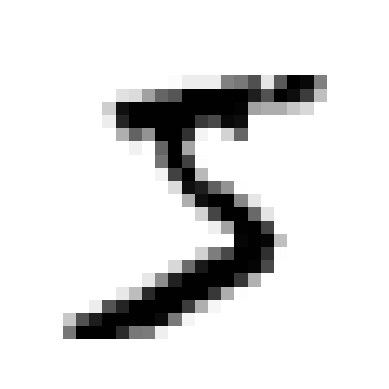

In [7]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)

In [8]:
y[0]

'5'

In [9]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

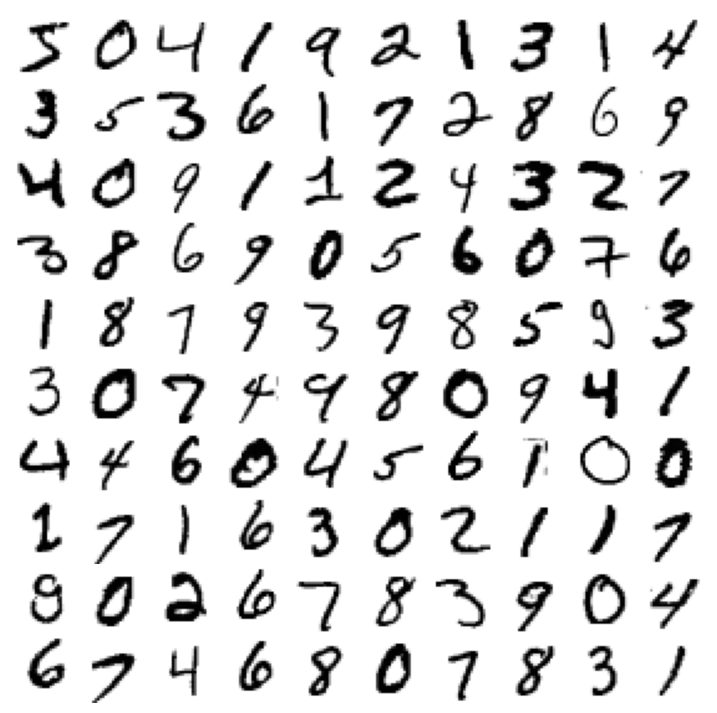

In [10]:
plt.figure(figsize=(9, 9))

for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)

plt.subplots_adjust(wspace=0, hspace=0)

In [11]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [12]:
from sklearn.linear_model import SGDClassifier

sgd_classifier = SGDClassifier(random_state=42)
sgd_classifier.fit(X_train, y_train_5)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [13]:
sgd_classifier.predict([some_digit])

array([ True])

In [14]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_classifier, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_classifier = DummyClassifier()
dummy_classifier.fit(X_train, y_train_5)
print(any(dummy_classifier.predict(X_train)))

False


In [17]:
cross_val_score(dummy_classifier, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

In [18]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

stratified_k_folds = StratifiedKFold(n_splits=3)

for train_index, test_index in stratified_k_folds.split(X_train, y_train_5):
    clone_classifier = clone(sgd_classifier)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_classifier.fit(X_train_folds, y_train_folds)
    y_predictions = clone_classifier.predict(X_test_fold)
    n_correct = sum(y_predictions == y_test_fold)
    print(n_correct / len(y_predictions))

0.95035
0.96035
0.9604


In [19]:
from sklearn.model_selection import cross_val_predict

y_train_prediction = cross_val_predict(sgd_classifier, X_train, y_train_5, cv=3)

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

confusion_mat = confusion_matrix(y_train_5, y_train_prediction)
confusion_mat

array([[53892,   687],
       [ 1891,  3530]])

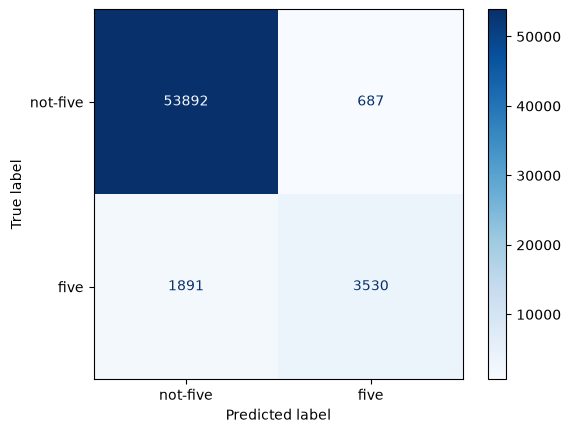

In [24]:
display = ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels=["not-five", "five"])
display.plot(cmap=plt.cm.Blues)

In [25]:
y_train_perfect_predictions = y_train_5
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

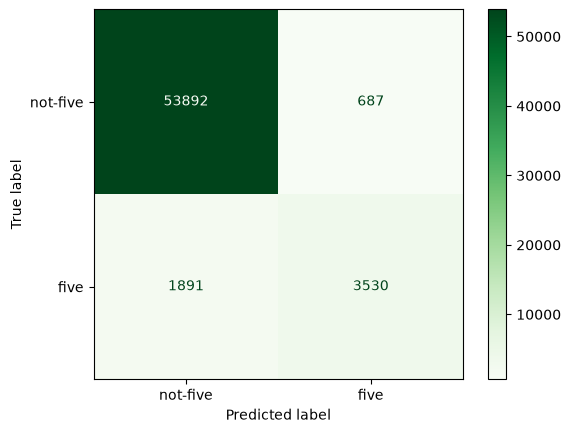

In [26]:
display = ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels=["not-five", "five"])
display.plot(cmap=plt.cm.Greens)

In [28]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_train_5, y_train_prediction)
recall = recall_score(y_train_5, y_train_prediction)
precision, recall

(0.8370879772350012, 0.6511713705958311)

In [30]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_prediction)

0.7325171197343847

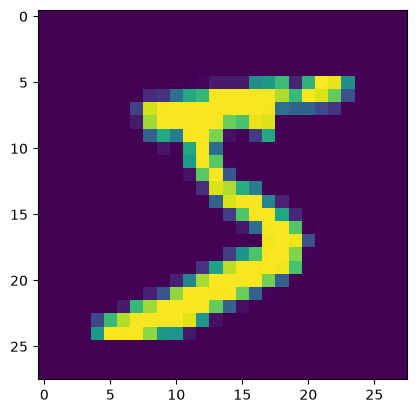

In [31]:
plt.imshow(some_digit.reshape(28, 28))

In [33]:
y_scores = sgd_classifier.decision_function([some_digit])
y_scores

array([2164.22030239])

In [34]:
threshold = 0
y_some_digit_prediction = (y_scores > threshold)
y_some_digit_prediction

array([ True])

In [35]:
threshold = 3000
y_some_digit_prediction = (y_scores > threshold)
y_some_digit_prediction

array([False])

In [36]:
y_scores = cross_val_predict(sgd_classifier, X_train, y_train_5, cv=3, method="decision_function")

In [37]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, threshold = precision_recall_curve(y_train_5, y_scores)